In [1]:
%pip install -q pytorch-lightning
%pip install matplotlib
%pip install scikit-learn
%pip install xgboost
%pip install lightgbm
%pip install nbformat
import plotly.io as pio
pio.renderers.default = "vscode"


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3.12 install --upgr

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
# Time series tools
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as L

np.random.seed(42)

#from google.colab import drive
#drive.mount('/content/gdrive')
print('All imports successful!')


All imports successful!


In [3]:
# load the dataset
# palmoil_df = pd.read_csv('/content/gdrive/MyDrive/PalmWatch/data/hex_deforestation_forecast.csv')
palmoil_df = pd.read_csv('/Users/Bohelan/Desktop/hex_deforestation_forecast.csv')
feature_names = ['nbr_r1_defor_frac', 'remaining_frac_hex', 'remaining_forest_ha', 
                 'remaining_frac_baseline', 'defor_frac','nbr_r1_remaining_frac_baseline' , 
                 'nbr_r2_defor_frac', 'degr_frac', 'target_total_5yr', 'target_palm_5yr']
neighbor_cols = ['nbr_r1_defor_frac', 'nbr_r2_defor_frac','nbr_r1_remaining_frac_baseline']
palmoil_df[neighbor_cols] = palmoil_df[neighbor_cols].fillna(0)

In [4]:
target_total = 'target_total_5yr'
df_2000_2018 = palmoil_df[palmoil_df["year"] <= 2018].copy()
hex_id_group_total = df_2000_2018.groupby("hex_id").agg(
        TotalCount=(target_total, "size"),
        MissingCount=(target_total, lambda x: x.isna().sum()),
        ZeroCount=(target_total, lambda x: (x == 0).sum()),
        NonZeroCount=(target_total, lambda x: (x > 0).sum()),
        ValidCount=(target_total, lambda x: ((x.notna()) & (x != 0)).sum()))
hex_id_group_total["ZeroRate"] = hex_id_group_total["ZeroCount"] / hex_id_group_total["TotalCount"]
hex_id_group_total["MissingRate"] = hex_id_group_total["MissingCount"] / hex_id_group_total["TotalCount"]
hex_id_group_total['ValidRate'] =hex_id_group_total['ValidCount']/ hex_id_group_total["TotalCount"]
hex_id_group_total.head()

,TotalCount,MissingCount,ZeroCount,NonZeroCount,ValidCount,ZeroRate,MissingRate,ValidRate
hex_id,,,,,,,,
86642c96fffffff,19,0,0,19,19,0.0,0.0,1.0
86650824fffffff,19,0,0,19,19,0.0,0.0,1.0
86650825fffffff,19,0,0,19,19,0.0,0.0,1.0
86650826fffffff,19,0,0,19,19,0.0,0.0,1.0
8665082cfffffff,19,0,0,19,19,0.0,0.0,1.0


In [5]:
# Group by hex_id and split the data into two groups:
# one with ValidRate >= 0.6 and the other with ValidRate < 0.6
high_valid_total = hex_id_group_total[hex_id_group_total["ValidRate"] >= 0.6]
low_valid_total = hex_id_group_total[hex_id_group_total["ValidRate"] < 0.6]
high_valid_rows_total = df_2000_2018[df_2000_2018["hex_id"].isin(high_valid_total.index)]
low_valid_rows_total = df_2000_2018[df_2000_2018["hex_id"].isin(low_valid_total.index)]
print(f"High ValidRate (>=0.6): {len(high_valid_total)} hex_id")
print(f"High ValidRate: {len(high_valid_rows_total)} rows")
print(f"Low ValidRate (<0.6): {len(low_valid_total)} hex_id")
print(f"Low ValidRate: {len(low_valid_rows_total)} rows")

High ValidRate (>=0.6): 8097 hex_id
High ValidRate: 153843 rows
Low ValidRate (<0.6): 611 hex_id
Low ValidRate: 11609 rows


In [6]:
# Variable name used for training(drop all Nah)
high_valid_df_total =palmoil_df[
        (palmoil_df["hex_id"].isin(high_valid_total.index)) &
        (palmoil_df["year"] >= 2000) &
        (palmoil_df["year"] <= 2018)].dropna().copy()
high_valid_df_total = high_valid_df_total.sort_values(["year","hex_id"])
high_valid_df_total

,hex_id,year,province,lat,lon,hex_area_km2,forest_2000_ha,forest_2000_frac,target_total_5yr,target_palm_5yr,defor_frac,degr_frac,remaining_frac_baseline,remaining_frac_hex,remaining_forest_ha,nbr_r1_defor_frac,nbr_r2_defor_frac,nbr_r1_remaining_frac_baseline
0,86642c96fffffff,2000,Aceh,5.864320,95.333609,43.2561,2009.9502,0.464663,0.075724,0.000000,0.000000,0.000000,1.000000,0.464663,2009.95,0.000000,0.000000,1.000000
24,86650824fffffff,2000,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.090693,0.060466,0.000000,0.000000,1.000000,0.644889,2765.64,0.000000,0.000000,1.000000
48,86650825fffffff,2000,Aceh,4.326226,98.222230,42.8941,1336.6519,0.311617,0.294264,0.101274,0.000000,0.000000,1.000000,0.311617,1336.65,0.000000,0.000000,1.000000
72,86650826fffffff,2000,SumateraUtara,4.217175,98.213308,42.8707,1908.7805,0.445241,0.073750,0.019868,0.000000,0.000000,1.000000,0.445241,1908.78,0.000000,0.000000,1.000000
96,8665082cfffffff,2000,Aceh,4.435317,98.231158,42.9171,2524.9166,0.588324,0.037826,0.033080,0.000000,0.000000,1.000000,0.588324,2524.92,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208884,868cf6d97ffffff,2012,SumateraSelatan,-3.531674,104.441285,38.8553,1335.0088,0.343585,0.090706,0.000390,0.060448,0.026119,0.686325,0.235811,916.25,0.055701,0.057745,0.625838
208908,868cf6d9fffffff,2012,SumateraSelatan,-3.527747,104.380681,38.8753,1034.8546,0.266198,0.164474,0.000880,0.070175,0.015881,0.588219,0.156583,608.72,0.049768,0.055513,0.672843
208932,868cf6da7ffffff,2012,SumateraSelatan,-3.634873,104.430766,38.8078,1258.0587,0.324177,0.183864,0.002504,0.062112,0.009809,0.566446,0.183629,712.62,0.052177,0.063470,0.568673
208956,868cf6dafffffff,2012,SumateraSelatan,-3.630964,104.370178,38.8278,2015.1737,0.519003,0.075305,0.000540,0.075300,0.020666,0.573835,0.297822,1156.38,0.054914,0.062750,0.554428


Palm

In [7]:
target_palm = 'target_palm_5yr'
df_2000_2012 = palmoil_df[palmoil_df["year"] <= 2012].copy()
hex_id_group_palm = df_2000_2012.groupby("hex_id").agg(
        TotalCount=(target_palm, "size"),
        MissingCount=(target_palm, lambda x: x.isna().sum()),
        ZeroCount=(target_palm, lambda x: (x == 0).sum()),
        NonZeroCount=(target_palm, lambda x: (x > 0).sum()),
        ValidCount=(target_palm, lambda x: ((x.notna()) & (x != 0)).sum()))
hex_id_group_palm["ZeroRate"] = hex_id_group_palm["ZeroCount"] / hex_id_group_palm["TotalCount"]
hex_id_group_palm["MissingRate"] = hex_id_group_palm["MissingCount"] / hex_id_group_palm["TotalCount"]
hex_id_group_palm['ValidRate'] =hex_id_group_palm['ValidCount']/ hex_id_group_palm["TotalCount"]
hex_id_group_palm.head()

,TotalCount,MissingCount,ZeroCount,NonZeroCount,ValidCount,ZeroRate,MissingRate,ValidRate
hex_id,,,,,,,,
86642c96fffffff,13,0,13,0,0,1.0,0.0,0.0
86650824fffffff,13,0,0,13,13,0.0,0.0,1.0
86650825fffffff,13,0,0,13,13,0.0,0.0,1.0
86650826fffffff,13,0,0,13,13,0.0,0.0,1.0
8665082cfffffff,13,0,0,13,13,0.0,0.0,1.0


In [8]:
# Group by hex_id and split the data into two groups:
# one with ValidRate >= 0.6 and the other with ValidRate < 0.5
high_valid_palm = hex_id_group_palm[hex_id_group_palm["ValidRate"] >= 0.5]
low_valid_palm = hex_id_group_palm[hex_id_group_palm["ValidRate"] < 0.5]
high_valid_rows_palm = df_2000_2012[df_2000_2012["hex_id"].isin(high_valid_palm.index)]
low_valid_rows_palm = df_2000_2012[df_2000_2012["hex_id"].isin(low_valid_palm.index)]
print(f"High ValidRate (>=0.5): {len(high_valid_palm)} hex_id")
print(f"High ValidRate: {len(high_valid_rows_palm)} rows")
print(f"Low ValidRate (<0.5): {len(low_valid_palm)} hex_id")
print(f"Low ValidRate: {len(low_valid_rows_palm)} rows")

High ValidRate (>=0.5): 4691 hex_id
High ValidRate: 60983 rows
Low ValidRate (<0.5): 4017 hex_id
Low ValidRate: 52221 rows


In [9]:
# Variable name used for training(drop all Nah)
high_valid_df_palm =palmoil_df[
        (palmoil_df["hex_id"].isin(high_valid_palm.index)) &
        (palmoil_df["year"] >= 2000) &
        (palmoil_df["year"] <= 2012)].dropna().copy()
high_valid_df_palm = high_valid_df_palm.sort_values(["year","hex_id"])
high_valid_df_palm

,hex_id,year,province,lat,lon,hex_area_km2,forest_2000_ha,forest_2000_frac,target_total_5yr,target_palm_5yr,defor_frac,degr_frac,remaining_frac_baseline,remaining_frac_hex,remaining_forest_ha,nbr_r1_defor_frac,nbr_r2_defor_frac,nbr_r1_remaining_frac_baseline
24,86650824fffffff,2000,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.090693,0.060466,0.000000,0.000000,1.000000,0.644889,2765.64,0.000000,0.000000,1.000000
48,86650825fffffff,2000,Aceh,4.326226,98.222230,42.8941,1336.6519,0.311617,0.294264,0.101274,0.000000,0.000000,1.000000,0.311617,1336.65,0.000000,0.000000,1.000000
72,86650826fffffff,2000,SumateraUtara,4.217175,98.213308,42.8707,1908.7805,0.445241,0.073750,0.019868,0.000000,0.000000,1.000000,0.445241,1908.78,0.000000,0.000000,1.000000
96,8665082cfffffff,2000,Aceh,4.435317,98.231158,42.9171,2524.9166,0.588324,0.037826,0.033080,0.000000,0.000000,1.000000,0.588324,2524.92,0.000000,0.000000,1.000000
120,8665082efffffff,2000,Aceh,4.378315,98.258395,42.9026,2933.7057,0.683806,0.025798,0.005888,0.000000,0.000000,1.000000,0.683806,2933.71,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208860,868cf6d8fffffff,2012,SumateraSelatan,-3.577405,104.345123,38.8616,1281.9089,0.329865,0.067022,0.000092,0.040372,0.011564,0.753434,0.248532,965.83,0.053603,0.059665,0.598694
208884,868cf6d97ffffff,2012,SumateraSelatan,-3.531674,104.441285,38.8553,1335.0088,0.343585,0.090706,0.000390,0.060448,0.026119,0.686325,0.235811,916.25,0.055701,0.057745,0.625838
208908,868cf6d9fffffff,2012,SumateraSelatan,-3.527747,104.380681,38.8753,1034.8546,0.266198,0.164474,0.000880,0.070175,0.015881,0.588219,0.156583,608.72,0.049768,0.055513,0.672843
208932,868cf6da7ffffff,2012,SumateraSelatan,-3.634873,104.430766,38.8078,1258.0587,0.324177,0.183864,0.002504,0.062112,0.009809,0.566446,0.183629,712.62,0.052177,0.063470,0.568673


Random Forest Total Prediction

In [10]:
feature_total_rf = ["defor_frac","remaining_frac_baseline",
              "defor_frac_lag1","remaining_frac_baseline_lag1","target_total_5yr_lag1",
              "defor_frac_lag2","remaining_frac_baseline_lag2","target_total_5yr_lag2"]
Target_total = "target_total_5yr"

In [11]:
# Select all high-valid hex IDs from 2000–2012
model_total_rf_round2 = palmoil_df[(palmoil_df["hex_id"].isin(high_valid_total.index)) &(palmoil_df["year"].between(2000, 2018))].copy()
model_total_rf_round2 = model_total_rf_round2.sort_values(["hex_id", "year"]).copy()

# Create lag-1 features within each hex_id
model_total_rf_round2["defor_frac_lag1"] = model_total_rf_round2.groupby("hex_id")["defor_frac"].shift(1)
model_total_rf_round2["remaining_frac_baseline_lag1"] = model_total_rf_round2.groupby("hex_id")["remaining_frac_baseline"].shift(1)
model_total_rf_round2["target_total_5yr_lag1"] = model_total_rf_round2.groupby("hex_id")[Target_total].shift(1)
model_total_rf_round2["defor_frac_lag2"] = model_total_rf_round2.groupby("hex_id")["defor_frac"].shift(2)
model_total_rf_round2["remaining_frac_baseline_lag2"] = model_total_rf_round2.groupby("hex_id")["remaining_frac_baseline"].shift(2)
model_total_rf_round2["target_total_5yr_lag2"] = model_total_rf_round2.groupby("hex_id")[Target_total].shift(2)

# Keep rows with complete training features and target
round2_train_total_rf = model_total_rf_round2.dropna(subset=feature_total_rf + [Target_total]).copy()

# Use all available 2000–2012 data for final training
X_train_total_rf_round2 = round2_train_total_rf[feature_total_rf]
y_train_total_rf_round2 = round2_train_total_rf[Target_total]

print("Training year range:",round2_train_total_rf["year"].min(),"-",round2_train_total_rf["year"].max())
print("Training rows:", len(round2_train_total_rf))
print("Number of hex IDs:", round2_train_total_rf["hex_id"].nunique())

# Best Random Forest
rf_total_round2 = RandomForestRegressor(n_estimators=500,max_depth=15,random_state=42)
rf_total_round2.fit(X_train_total_rf_round2, y_train_total_rf_round2)
print("Random Forest trained successfully.")

Training year range: 2002 - 2018
Training rows: 136955
Number of hex IDs: 8097
Random Forest trained successfully.


In [12]:
# Final Recursive Forecast (2019–2023)
# Build feature history
feature_history_round2_rf_total = palmoil_df[(palmoil_df["hex_id"].isin(high_valid_total.index)) &(palmoil_df["year"].between(2000, 2023))].copy()
feature_history_round2_rf_total = feature_history_round2_rf_total.sort_values(["hex_id", "year"]).copy()

# Create lag features
feature_history_round2_rf_total["defor_frac_lag1"] = feature_history_round2_rf_total.groupby("hex_id")["defor_frac"].shift(1)
feature_history_round2_rf_total["remaining_frac_baseline_lag1"] = feature_history_round2_rf_total.groupby("hex_id")["remaining_frac_baseline"].shift(1)
feature_history_round2_rf_total["target_total_5yr_lag1"] = feature_history_round2_rf_total.groupby("hex_id")[Target_total].shift(1)
feature_history_round2_rf_total["defor_frac_lag2"] = feature_history_round2_rf_total.groupby("hex_id")["defor_frac"].shift(2)
feature_history_round2_rf_total["remaining_frac_baseline_lag2"] = feature_history_round2_rf_total.groupby("hex_id")["remaining_frac_baseline"].shift(2)
feature_history_round2_rf_total["target_total_5yr_lag2"] = feature_history_round2_rf_total.groupby("hex_id")[Target_total].shift(2)

# Forecast period
future_prediction_total_rf_round2 = feature_history_round2_rf_total[feature_history_round2_rf_total["year"].between(2019, 2023)].copy()

prediction_results_total_rf_round2 = []
for year in range(2019, 2024):
    current_year_total = future_prediction_total_rf_round2[future_prediction_total_rf_round2["year"] == year].copy()
    # Keep rows with complete features
    current_year_total = current_year_total.dropna(subset=feature_total_rf).copy()
    if current_year_total.empty:
        print(f"{year}: no valid rows")
        continue

    # Predict
    current_year_total["predicted_target_total_5yr"] = rf_total_round2.predict(current_year_total[feature_total_rf])
    prediction_results_total_rf_round2.append(current_year_total)
    print(f"{year}: predicted {len(current_year_total)} rows, "
          f"mean prediction = "f"{current_year_total['predicted_target_total_5yr'].mean()}")

    # Update lag1 & lag2 for next year
    next_year = year + 1
    if next_year <= 2023:
        mask = feature_history_round2_rf_total["year"] == next_year
        # lag1 = current year's prediction
        feature_history_round2_rf_total.loc[mask,"target_total_5yr_lag1"] = (feature_history_round2_rf_total.loc[mask, "hex_id"]
            .map(current_year_total.set_index("hex_id")["predicted_target_total_5yr"]))

        # lag2 = previous year's lag1
        feature_history_round2_rf_total.loc[mask,"target_total_5yr_lag2"] = (feature_history_round2_rf_total.loc[mask, "hex_id"]
            .map(current_year_total.set_index("hex_id")[ "target_total_5yr_lag1"]))
        # Refresh future dataframe
        future_prediction_total_rf_round2 = feature_history_round2_rf_total[feature_history_round2_rf_total["year"].between(2019, 2023)].copy()

# Combine all forecast years
final_prediction_total_rf_round2 = pd.concat(prediction_results_total_rf_round2,ignore_index=True)
final_prediction_total_rf_round2 = final_prediction_total_rf_round2.sort_values(["hex_id", "year"]).reset_index(drop=True)
final_prediction_total_rf_round2.head()

2019: predicted 7932 rows, mean prediction = 0.08578793587102086
2020: predicted 7932 rows, mean prediction = 0.08950252453547365
2021: predicted 7932 rows, mean prediction = 0.0920024660743443
2022: predicted 7932 rows, mean prediction = 0.09347877186684565
2023: predicted 7932 rows, mean prediction = 0.0975446775885625


,hex_id,year,province,lat,lon,hex_area_km2,forest_2000_ha,forest_2000_frac,target_total_5yr,target_palm_5yr,...,nbr_r1_defor_frac,nbr_r2_defor_frac,nbr_r1_remaining_frac_baseline,defor_frac_lag1,remaining_frac_baseline_lag1,target_total_5yr_lag1,defor_frac_lag2,remaining_frac_baseline_lag2,target_total_5yr_lag2,predicted_target_total_5yr
0,86642c96fffffff,2019,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.001762,0.0,0.943605,0.002076,0.849913,0.022086,0.010251,0.851989,0.020418,0.020033
1,86642c96fffffff,2020,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.003030,0.0,0.940576,0.005487,0.844426,0.020033,0.002076,0.849913,0.022086,0.018090
2,86642c96fffffff,2021,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.001531,0.0,0.939045,0.005398,0.839028,0.018090,0.005487,0.844426,0.020033,0.025042
3,86642c96fffffff,2022,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.003639,0.0,0.935406,0.000708,0.838320,0.025042,0.005398,0.839028,0.018090,0.028738
4,86642c96fffffff,2023,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.002008,0.0,0.933398,0.003727,0.834593,0.028738,0.000708,0.838320,0.025042,0.032555


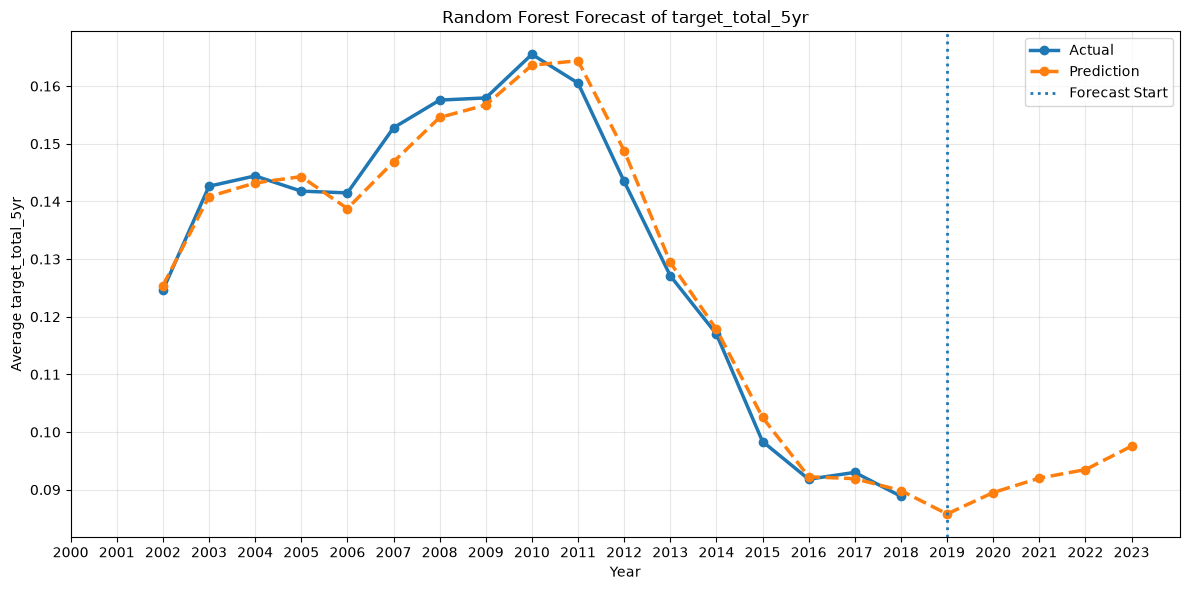

In [13]:
# Actual (2000–2018)
actual_total_rf = round2_train_total_rf.groupby("year")[Target_total].mean()

# Prediction (2000–2018)
round2_train_total_rf["predicted_target_total_5yr"] = rf_total_round2.predict(round2_train_total_rf[feature_total_rf])
train_prediction_total_rf = round2_train_total_rf.groupby("year")["predicted_target_total_5yr"].mean()

# Forecast (2019–2023)
forecast_prediction_total_rf = final_prediction_total_rf_round2.groupby("year")["predicted_target_total_5yr"].mean()

# Combine Prediction (2000–2023)
prediction_total_rf = pd.concat([train_prediction_total_rf, forecast_prediction_total_rf]).sort_index()

# Plot
plt.figure(figsize=(12,6))
plt.plot(actual_total_rf.index, actual_total_rf.values, "o-", lw=2.5, label="Actual")
plt.plot(prediction_total_rf.index, prediction_total_rf.values, "o--", lw=2.5, label="Prediction")
plt.axvline(2019, ls=":", lw=2, label="Forecast Start")

plt.title("Random Forest Forecast of target_total_5yr")
plt.xlabel("Year")
plt.ylabel("Average target_total_5yr")
plt.xticks(range(2000,2024))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Random Forest Oil Palm Deforestation

In [14]:
feature_rf = [ "defor_frac", "remaining_frac_baseline","defor_frac_lag1","remaining_frac_baseline_lag1", "target_palm_5yr_lag1"]
Target_palm = "target_palm_5yr"

# Select all high-valid hex IDs from 2000–2012
model_rf = palmoil_df[(palmoil_df["hex_id"].isin(high_valid_palm.index)) &(palmoil_df["year"].between(2000, 2012))].copy()
model_rf = model_rf.sort_values(["hex_id", "year"]).copy()

# Create lag-1 features within each hex_id
model_rf["defor_frac_lag1"] =  model_rf.groupby("hex_id")["defor_frac"].shift(1)
model_rf["remaining_frac_baseline_lag1"] = model_rf.groupby("hex_id")["remaining_frac_baseline"].shift(1)
model_rf["target_palm_5yr_lag1"] = model_rf.groupby("hex_id")[Target_palm].shift(1)

# Keep rows with complete training features and target
final_train_rf = model_rf.dropna(subset=feature_rf + [Target_palm]).copy()

# Use all available 2000–2012 data for final training
X_train = final_train_rf[feature_rf]
y_train = final_train_rf[Target_palm]

print("Training year range:",final_train_rf["year"].min(),"-",final_train_rf["year"].max())
print("Training rows:", len(final_train_rf))
print("Number of hex IDs:", final_train_rf["hex_id"].nunique())

# Best Random Forest
rf_palm = RandomForestRegressor(n_estimators=50,max_depth=10,min_samples_leaf=5,random_state=42)
rf_palm.fit(X_train, y_train)
print("Random Forest trained successfully.")

Training year range: 2001 - 2012
Training rows: 56066
Number of hex IDs: 4691
Random Forest trained successfully.


In [15]:
# Because we have to take lag, so remember to check all valid hex_id
feature_history_rf = palmoil_df[(palmoil_df["hex_id"].isin(high_valid_palm.index)) &(palmoil_df["year"].between(2000, 2023))].copy()
feature_history_rf = feature_history_rf.sort_values(["hex_id", "year"]).copy()
feature_history_rf["defor_frac_lag1"] = feature_history_rf.groupby("hex_id")["defor_frac"].shift(1)
feature_history_rf["remaining_frac_baseline_lag1"] = feature_history_rf.groupby("hex_id")["remaining_frac_baseline"].shift(1)
future_prediction_palm_rf = feature_history_rf[feature_history_rf["year"].between(2013, 2023)].copy()
previous_year_target = feature_history_rf[feature_history_rf["year"] == 2012][["hex_id", Target_palm]].dropna(subset=[Target_palm]).rename(columns={Target_palm: "target_palm_5yr_lag1"})
prediction_results_palm_rf = []
for year in range(2013, 2024):
    # Select the data for the current year
    current_year = future_prediction_palm_rf[future_prediction_palm_rf["year"] == year].copy()
    # Add the previous year's target
    # 2013 uses actual 2012 target
    # 2014–2023 use the previous year's prediction
    current_year = current_year.merge(previous_year_target,on="hex_id",how="left")
    # Keep only rows with all required features
    current_year = current_year.dropna( subset=feature_rf).copy()
    if current_year.empty:
        print(f"{year}: no valid rows predict")
        break

    # Predict the current year(The year now we will predict, including the 2 features and their lag in previous year beside the lag target)
    current_year["predicted_target_palm_5yr"] = rf_palm.predict(current_year[feature_rf])
    prediction_results_palm_rf.append(current_year)
    print( f"{year}: predicted {len(current_year)} rows, " f"average prediction = " f"{current_year['predicted_target_palm_5yr'].mean()}")
    # Use the current prediction as the target lag for next year
    previous_year_target = current_year[["hex_id", "predicted_target_palm_5yr"]].rename(columns={"predicted_target_palm_5yr":"target_palm_5yr_lag1"})

# Combine predictions from all years
final_prediction_palm_rf = pd.concat(prediction_results_palm_rf,ignore_index=True)
final_prediction_palm_rf = final_prediction_palm_rf.sort_values(["hex_id", "year"]).reset_index(drop=True)
final_prediction_palm_rf.head()

2013: predicted 4615 rows, average prediction = 0.052708124245807036
2014: predicted 4615 rows, average prediction = 0.04889186784498492
2015: predicted 4615 rows, average prediction = 0.04527453388073465
2016: predicted 4615 rows, average prediction = 0.04302055833400336
2017: predicted 4615 rows, average prediction = 0.04251005761641064
2018: predicted 4615 rows, average prediction = 0.041222863462621384
2019: predicted 4615 rows, average prediction = 0.040348778197448476
2020: predicted 4615 rows, average prediction = 0.042213109617664446
2021: predicted 4615 rows, average prediction = 0.043960134434875724
2022: predicted 4615 rows, average prediction = 0.04619410644400508
2023: predicted 4615 rows, average prediction = 0.049948727725000586


,hex_id,year,province,lat,lon,hex_area_km2,forest_2000_ha,forest_2000_frac,target_total_5yr,target_palm_5yr,...,remaining_frac_baseline,remaining_frac_hex,remaining_forest_ha,nbr_r1_defor_frac,nbr_r2_defor_frac,nbr_r1_remaining_frac_baseline,defor_frac_lag1,remaining_frac_baseline_lag1,target_palm_5yr_lag1,predicted_target_palm_5yr
0,86650824fffffff,2013,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.737388,NaN,...,0.182911,0.117957,505.87,0.032895,0.028270,0.637797,0.029165,0.224119,0.663547,0.647602
1,86650824fffffff,2014,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.478862,NaN,...,0.088063,0.056791,243.55,0.065795,0.041538,0.572002,0.041209,0.182911,0.647602,0.439926
2,86650824fffffff,2015,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.306258,NaN,...,0.062714,0.040444,173.44,0.031697,0.034818,0.540305,0.094848,0.088063,0.439926,0.379439
3,86650824fffffff,2016,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.251793,NaN,...,0.056900,0.036694,157.36,0.011762,0.017866,0.528543,0.025349,0.062714,0.379439,0.395534
4,86650824fffffff,2017,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.285792,NaN,...,0.056578,0.036486,156.47,0.002908,0.006376,0.525636,0.005814,0.056900,0.395534,0.433199


In [16]:
# Training prediction (2000–2012)
train_prediction_palm_rf = model_rf.dropna(subset=feature_rf + [Target_palm]).copy()
train_prediction_palm_rf["predicted_target_palm_5yr"] = rf_palm.predict(train_prediction_palm_rf[feature_rf])
actual_mean_palm_rf = train_prediction_palm_rf.groupby("year")[Target_palm].mean()
pred_train_mean_palm_rf = train_prediction_palm_rf.groupby("year")["predicted_target_palm_5yr"].mean()

# Future prediction (2013–2023)
pred_future_mean_palm_rf = final_prediction_palm_rf.groupby("year")["predicted_target_palm_5yr"].mean()
# Prediction (2000–2023)
prediction_mean_palm_rf = pd.concat([pred_train_mean_palm_rf, pred_future_mean_palm_rf]).sort_index()
# Training metrics
train_rmse_palm_rf = np.sqrt(mean_squared_error(train_prediction_palm_rf[Target_palm], train_prediction_palm_rf["predicted_target_palm_5yr"]))
train_mae_palm_rf = mean_absolute_error(train_prediction_palm_rf[Target_palm], train_prediction_palm_rf["predicted_target_palm_5yr"])
print("Training RMSE:", train_rmse_palm_rf)
print("Training MAE:", train_mae_palm_rf)

Training RMSE: 0.028155462631537245
Training MAE: 0.011824800151890703


Plot of Random Forest Prediction for two prediction goals

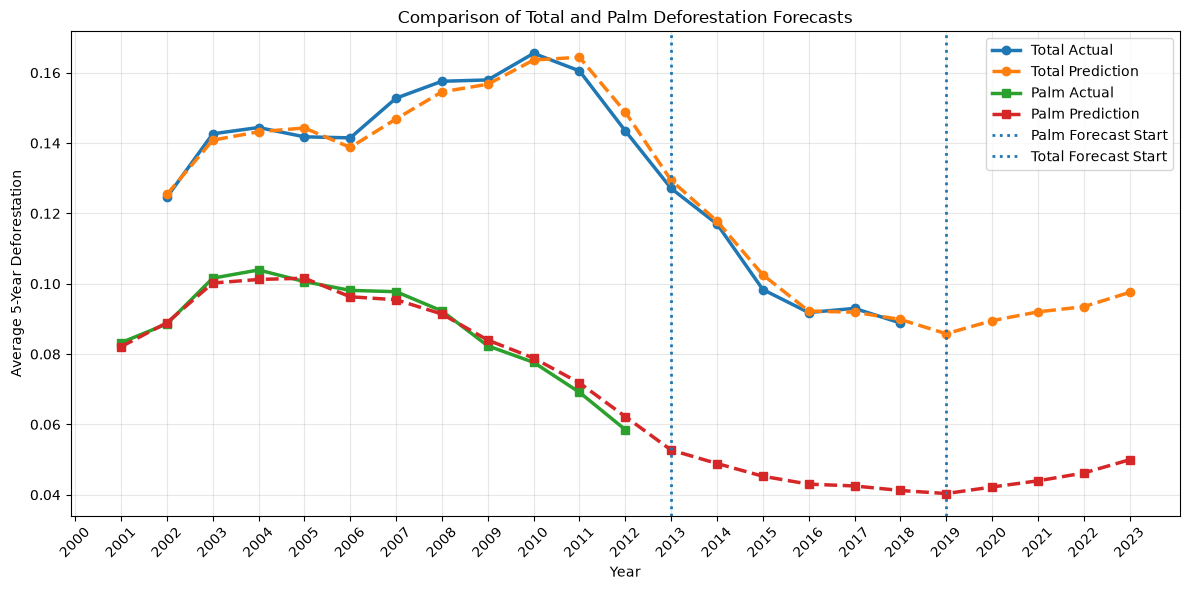

In [17]:
plt.figure(figsize=(12,6))
plt.plot(actual_total_rf.index,actual_total_rf.values,"o-",lw=2.5,label="Total Actual")
plt.plot(prediction_total_rf.index,prediction_total_rf.values,"o--",lw=2.5,label="Total Prediction")

plt.plot(actual_mean_palm_rf.index,actual_mean_palm_rf.values,"s-",lw=2.5,label="Palm Actual")
plt.plot(prediction_mean_palm_rf.index,prediction_mean_palm_rf.values,"s--",lw=2.5,label="Palm Prediction")

plt.axvline(2013,ls=":",lw=2,label="Palm Forecast Start")
plt.axvline(2019,ls=":",lw=2,label="Total Forecast Start")

plt.title("Comparison of Total and Palm Deforestation Forecasts")
plt.xlabel("Year")
plt.ylabel("Average 5-Year Deforestation")
plt.xticks(range(2000,2024),rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

XGBoost Total Prediction

In [18]:
# XGBoost feature set for Total prediction
feature_total_xg = [
    "defor_frac", "remaining_frac_baseline",
    "defor_frac_lag1", "remaining_frac_baseline_lag1", "target_total_5yr_lag1",
    "defor_frac_lag2", "remaining_frac_baseline_lag2", "target_total_5yr_lag2",
    "defor_frac_lag3", "remaining_frac_baseline_lag3", "target_total_5yr_lag3",
    "defor_frac_lag4", "remaining_frac_baseline_lag4", "target_total_5yr_lag4"
]
Target_total = "target_total_5yr"


In [19]:
# Final XGBoost training for Total target: 2000–2018
model_total_xg_round2 = palmoil_df[(palmoil_df["hex_id"].isin(high_valid_total.index)) &
                                   (palmoil_df["year"].between(2000, 2018))].copy().sort_values(["hex_id", "year"])

# Create lag 1–4 features consistently with feature_total_xg
for lag in [1, 2, 3, 4]:
    model_total_xg_round2[f"defor_frac_lag{lag}"] = model_total_xg_round2.groupby("hex_id")["defor_frac"].shift(lag)
    model_total_xg_round2[f"remaining_frac_baseline_lag{lag}"] =  model_total_xg_round2.groupby("hex_id")["remaining_frac_baseline"].shift(lag)
    model_total_xg_round2[f"target_total_5yr_lag{lag}"] = model_total_xg_round2.groupby("hex_id")[Target_total].shift(lag)

# Keep XGBoost variables separate from Random Forest variables
round2_train_total_xg = model_total_xg_round2.dropna(subset=feature_total_xg + [Target_total]).copy()

X_train_total_xg_round2 = round2_train_total_xg[feature_total_xg]
y_train_total_xg_round2 = round2_train_total_xg[Target_total]

print("Training year range:", round2_train_total_xg["year"].min(), "-", round2_train_total_xg["year"].max())
print("Training rows:", len(round2_train_total_xg))
print("Number of hex IDs:", round2_train_total_xg["hex_id"].nunique())

xg_total_round2 = XGBRegressor(n_estimators=200, max_depth=6,learning_rate=0.05,random_state=42)
xg_total_round2.fit(X_train_total_xg_round2, y_train_total_xg_round2)
print("XGBoost Total model trained successfully.")


Training year range: 2004 - 2018
Training rows: 120761
Number of hex IDs: 8097
XGBoost Total model trained successfully.


In [20]:
# Final recursive XGBoost forecast for Total target: 2019–2023
feature_history_total_xg = palmoil_df[(palmoil_df["hex_id"].isin(high_valid_total.index)) &
                                      (palmoil_df["year"].between(2000, 2023))].copy().sort_values(["hex_id", "year"])

for lag in [1, 2, 3, 4]:
    feature_history_total_xg[f"defor_frac_lag{lag}"] = feature_history_total_xg.groupby("hex_id")["defor_frac"].shift(lag)
    feature_history_total_xg[f"remaining_frac_baseline_lag{lag}"] = feature_history_total_xg.groupby("hex_id")["remaining_frac_baseline"].shift(lag)
    feature_history_total_xg[f"target_total_5yr_lag{lag}"] = feature_history_total_xg.groupby("hex_id")[Target_total].shift(lag)

prediction_results_total_xg = []

for year in range(2019, 2024):
    current_year_total_xg = feature_history_total_xg[feature_history_total_xg["year"] == year].copy()
    current_year_total_xg = current_year_total_xg.dropna(subset=feature_total_xg).copy()

    if current_year_total_xg.empty:
        print(f"{year}: no valid rows")
        continue

    current_year_total_xg["predicted_target_total_5yr"] = xg_total_round2.predict(current_year_total_xg[feature_total_xg])
    prediction_results_total_xg.append(current_year_total_xg)

    print(f"{year}: predicted {len(current_year_total_xg)} rows, "
          f"mean prediction = {current_year_total_xg['predicted_target_total_5yr'].mean()}")

    # Shift recursive target lags into the next year.
    next_year = year + 1
    if next_year <= 2023:
        current_by_hex = current_year_total_xg.set_index("hex_id")
        next_mask = feature_history_total_xg["year"] == next_year
        next_hex = feature_history_total_xg.loc[next_mask, "hex_id"]

        feature_history_total_xg.loc[next_mask, "target_total_5yr_lag1"] = next_hex.map( current_by_hex["predicted_target_total_5yr"])
        for lag in [2, 3, 4]:
            feature_history_total_xg.loc[next_mask, f"target_total_5yr_lag{lag}"] = next_hex.map(current_by_hex[f"target_total_5yr_lag{lag-1}"])

final_prediction_total_xg_round2 = pd.concat(prediction_results_total_xg, ignore_index=True).sort_values(["hex_id", "year"]).reset_index(drop=True)

# Actual, fitted, and future annual means for the final plot
actual_total_xg = round2_train_total_xg.groupby("year")[Target_total].mean()

train_prediction_total_xg = round2_train_total_xg.copy()
train_prediction_total_xg["predicted_target_total_5yr"] = xg_total_round2.predict(train_prediction_total_xg[feature_total_xg])
pred_train_total_xg = train_prediction_total_xg.groupby("year")["predicted_target_total_5yr"].mean()
pred_future_total_xg = final_prediction_total_xg_round2.groupby("year")["predicted_target_total_5yr"].mean()
prediction_total_xg = pd.concat([pred_train_total_xg, pred_future_total_xg]).sort_index()

final_prediction_total_xg_round2.head()


2019: predicted 7932 rows, mean prediction = 0.08531075716018677
2020: predicted 7932 rows, mean prediction = 0.087613046169281
2021: predicted 7932 rows, mean prediction = 0.08706646412611008
2022: predicted 7932 rows, mean prediction = 0.08481068909168243
2023: predicted 7932 rows, mean prediction = 0.08368281275033951


,hex_id,year,province,lat,lon,hex_area_km2,forest_2000_ha,forest_2000_frac,target_total_5yr,target_palm_5yr,...,defor_frac_lag2,remaining_frac_baseline_lag2,target_total_5yr_lag2,defor_frac_lag3,remaining_frac_baseline_lag3,target_total_5yr_lag3,defor_frac_lag4,remaining_frac_baseline_lag4,target_total_5yr_lag4,predicted_target_total_5yr
0,86642c96fffffff,2019,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.010251,0.851989,0.020418,0.001106,0.862240,0.027741,0.002876,0.863346,0.028167,0.020522
1,86642c96fffffff,2020,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.002076,0.849913,0.022086,0.010251,0.851989,0.020418,0.001106,0.862240,0.027741,0.019848
2,86642c96fffffff,2021,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.005487,0.844426,0.020522,0.002076,0.849913,0.022086,0.010251,0.851989,0.020418,0.024378
3,86642c96fffffff,2022,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.005398,0.839028,0.019848,0.005487,0.844426,0.020522,0.002076,0.849913,0.022086,0.025932
4,86642c96fffffff,2023,Aceh,5.86432,95.333609,43.2561,2009.9502,0.464663,NaN,NaN,...,0.000708,0.838320,0.024378,0.005398,0.839028,0.019848,0.005487,0.844426,0.020522,0.026955


XGBoost of Palm Prediction

In [21]:
# Final XGBoost training for Palm target: 2000–2012
feature_palm_xg = ["defor_frac", "remaining_frac_baseline",
                   "defor_frac_lag1", "remaining_frac_baseline_lag1", "target_palm_5yr_lag1"]
Target_palm = "target_palm_5yr"

model_palm_xg = palmoil_df[(palmoil_df["hex_id"].isin(high_valid_palm.index)) &(palmoil_df["year"].between(2000, 2012))].copy().sort_values(["hex_id", "year"])

model_palm_xg["defor_frac_lag1"] = model_palm_xg.groupby("hex_id")["defor_frac"].shift(1)
model_palm_xg["remaining_frac_baseline_lag1"] = model_palm_xg.groupby("hex_id")["remaining_frac_baseline"].shift(1)
model_palm_xg["target_palm_5yr_lag1"] = model_palm_xg.groupby("hex_id")[Target_palm].shift(1)

final_train_palm_xg = model_palm_xg.dropna( subset=feature_palm_xg + [Target_palm]).copy()

X_train_palm_xg = final_train_palm_xg[feature_palm_xg]
y_train_palm_xg = final_train_palm_xg[Target_palm]

print("Training year range:", final_train_palm_xg["year"].min(), "-", final_train_palm_xg["year"].max())
print("Training rows:", len(final_train_palm_xg))
print("Number of hex IDs:", final_train_palm_xg["hex_id"].nunique())

xg_palm = XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.05,random_state=42)
xg_palm.fit(X_train_palm_xg, y_train_palm_xg)
print("XGBoost Palm model trained successfully.")


Training year range: 2001 - 2012
Training rows: 56066
Number of hex IDs: 4691
XGBoost Palm model trained successfully.


In [22]:
# Final recursive XGBoost forecast for Palm target: 2013–2023
feature_history_palm_xg = palmoil_df[(palmoil_df["hex_id"].isin(high_valid_palm.index)) &
                                     (palmoil_df["year"].between(2000, 2023))].copy().sort_values(["hex_id", "year"])

feature_history_palm_xg["defor_frac_lag1"] = feature_history_palm_xg.groupby("hex_id")["defor_frac"].shift(1)
feature_history_palm_xg["remaining_frac_baseline_lag1"] = feature_history_palm_xg.groupby("hex_id")["remaining_frac_baseline"].shift(1)

future_prediction_palm_xg = feature_history_palm_xg[feature_history_palm_xg["year"].between(2013, 2023)].copy()

previous_year_target_palm_xg = feature_history_palm_xg[feature_history_palm_xg["year"] == 2012][["hex_id", Target_palm]].dropna(subset=[Target_palm]).rename(columns={Target_palm: "target_palm_5yr_lag1"})
prediction_results_palm_xg = []
for year in range(2013, 2024):
    current_year_palm_xg = future_prediction_palm_xg[future_prediction_palm_xg["year"] == year].copy()
    current_year_palm_xg = current_year_palm_xg.merge(previous_year_target_palm_xg, on="hex_id", how="left")
    current_year_palm_xg = current_year_palm_xg.dropna(subset=feature_palm_xg).copy()

    if current_year_palm_xg.empty:
        print(f"{year}: no valid rows to predict")
        break

    current_year_palm_xg["predicted_target_palm_5yr"] = xg_palm.predict( current_year_palm_xg[feature_palm_xg])
    prediction_results_palm_xg.append(current_year_palm_xg)

    print(f"{year}: predicted {len(current_year_palm_xg)} rows, "
          f"average prediction = {current_year_palm_xg['predicted_target_palm_5yr'].mean()}")

    previous_year_target_palm_xg = current_year_palm_xg[["hex_id", "predicted_target_palm_5yr"]].rename(columns={"predicted_target_palm_5yr": "target_palm_5yr_lag1"})

final_prediction_palm_xg = pd.concat(prediction_results_palm_xg, ignore_index=True).sort_values(["hex_id", "year"]).reset_index(drop=True)
final_prediction_palm_xg.head()


2013: predicted 4615 rows, average prediction = 0.05180252715945244
2014: predicted 4615 rows, average prediction = 0.047414086759090424
2015: predicted 4615 rows, average prediction = 0.04298129677772522
2016: predicted 4615 rows, average prediction = 0.04035836458206177
2017: predicted 4615 rows, average prediction = 0.03959014266729355
2018: predicted 4615 rows, average prediction = 0.03765033558011055
2019: predicted 4615 rows, average prediction = 0.036657292395830154
2020: predicted 4615 rows, average prediction = 0.038850683718919754
2021: predicted 4615 rows, average prediction = 0.04053547978401184
2022: predicted 4615 rows, average prediction = 0.0433296263217926
2023: predicted 4615 rows, average prediction = 0.04753734543919563


,hex_id,year,province,lat,lon,hex_area_km2,forest_2000_ha,forest_2000_frac,target_total_5yr,target_palm_5yr,...,remaining_frac_baseline,remaining_frac_hex,remaining_forest_ha,nbr_r1_defor_frac,nbr_r2_defor_frac,nbr_r1_remaining_frac_baseline,defor_frac_lag1,remaining_frac_baseline_lag1,target_palm_5yr_lag1,predicted_target_palm_5yr
0,86650824fffffff,2013,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.737388,NaN,...,0.182911,0.117957,505.87,0.032895,0.028270,0.637797,0.029165,0.224119,0.663547,0.644292
1,86650824fffffff,2014,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.478862,NaN,...,0.088063,0.056791,243.55,0.065795,0.041538,0.572002,0.041209,0.182911,0.644292,0.437876
2,86650824fffffff,2015,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.306258,NaN,...,0.062714,0.040444,173.44,0.031697,0.034818,0.540305,0.094848,0.088063,0.437876,0.360899
3,86650824fffffff,2016,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.251793,NaN,...,0.056900,0.036694,157.36,0.011762,0.017866,0.528543,0.025349,0.062714,0.360899,0.340449
4,86650824fffffff,2017,SumateraUtara,4.274142,98.186076,42.8855,2765.6401,0.644889,0.285792,NaN,...,0.056578,0.036486,156.47,0.002908,0.006376,0.525636,0.005814,0.056900,0.340449,0.394796


In [23]:
# XGBoost Palm annual actual and prediction series
train_prediction_palm_xg = final_train_palm_xg.copy()

train_prediction_palm_xg["predicted_target_palm_5yr"] = xg_palm.predict(train_prediction_palm_xg[feature_palm_xg])

actual_mean_palm_xg = train_prediction_palm_xg.groupby("year")[Target_palm].mean()
pred_train_mean_palm_xg = train_prediction_palm_xg.groupby("year")["predicted_target_palm_5yr"].mean()
pred_future_mean_palm_xg = final_prediction_palm_xg.groupby("year")["predicted_target_palm_5yr"].mean()
prediction_mean_palm_xg = pd.concat([pred_train_mean_palm_xg, pred_future_mean_palm_xg]).sort_index()

train_rmse_palm_xg = np.sqrt(mean_squared_error(train_prediction_palm_xg[Target_palm],train_prediction_palm_xg["predicted_target_palm_5yr"]))
train_mae_palm_xg = mean_absolute_error(train_prediction_palm_xg[Target_palm],train_prediction_palm_xg["predicted_target_palm_5yr"])
print("XGBoost Palm training RMSE:", train_rmse_palm_xg)
print("XGBoost Palm training MAE:", train_mae_palm_xg)


XGBoost Palm training RMSE: 0.028883439178046182
XGBoost Palm training MAE: 0.012401303659110855


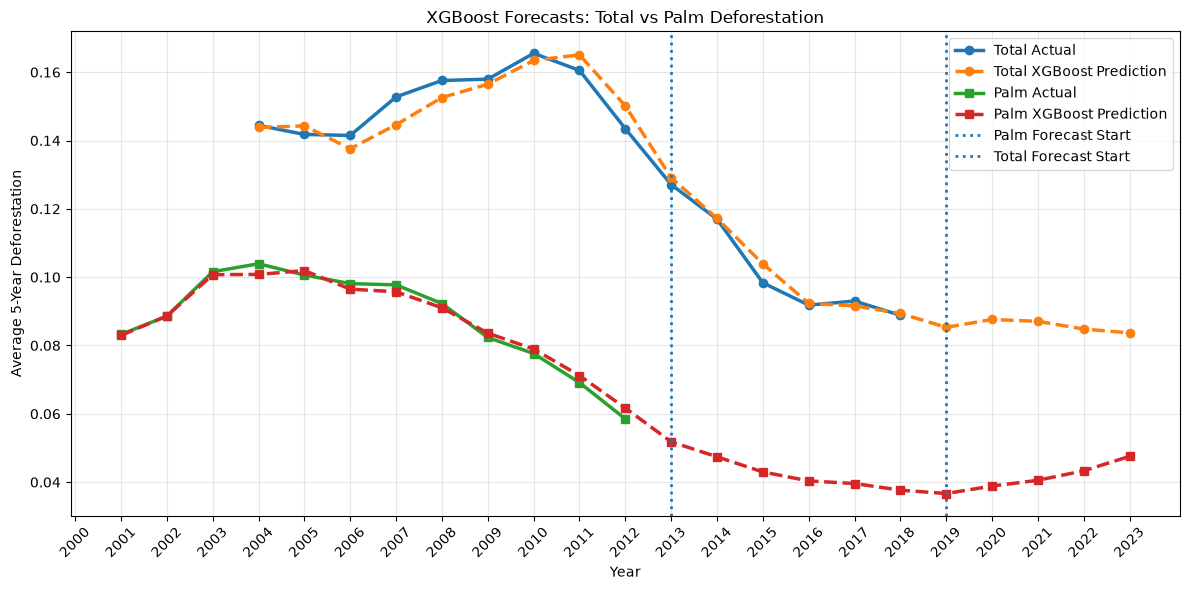

In [24]:
# XGBoost-only final plot: Total and Palm
plt.figure(figsize=(12, 6))

plt.plot(actual_total_xg.index, actual_total_xg.values, "o-", lw=2.5, label="Total Actual")
plt.plot(prediction_total_xg.index, prediction_total_xg.values, "o--", lw=2.5, label="Total XGBoost Prediction")

plt.plot(actual_mean_palm_xg.index, actual_mean_palm_xg.values, "s-", lw=2.5, label="Palm Actual")
plt.plot(prediction_mean_palm_xg.index, prediction_mean_palm_xg.values, "s--", lw=2.5, label="Palm XGBoost Prediction")

plt.axvline(2013, ls=":", lw=2, label="Palm Forecast Start")
plt.axvline(2019, ls=":", lw=2, label="Total Forecast Start")

plt.title("XGBoost Forecasts: Total vs Palm Deforestation")
plt.xlabel("Year")
plt.ylabel("Average 5-Year Deforestation")
plt.xticks(range(2000, 2024), rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


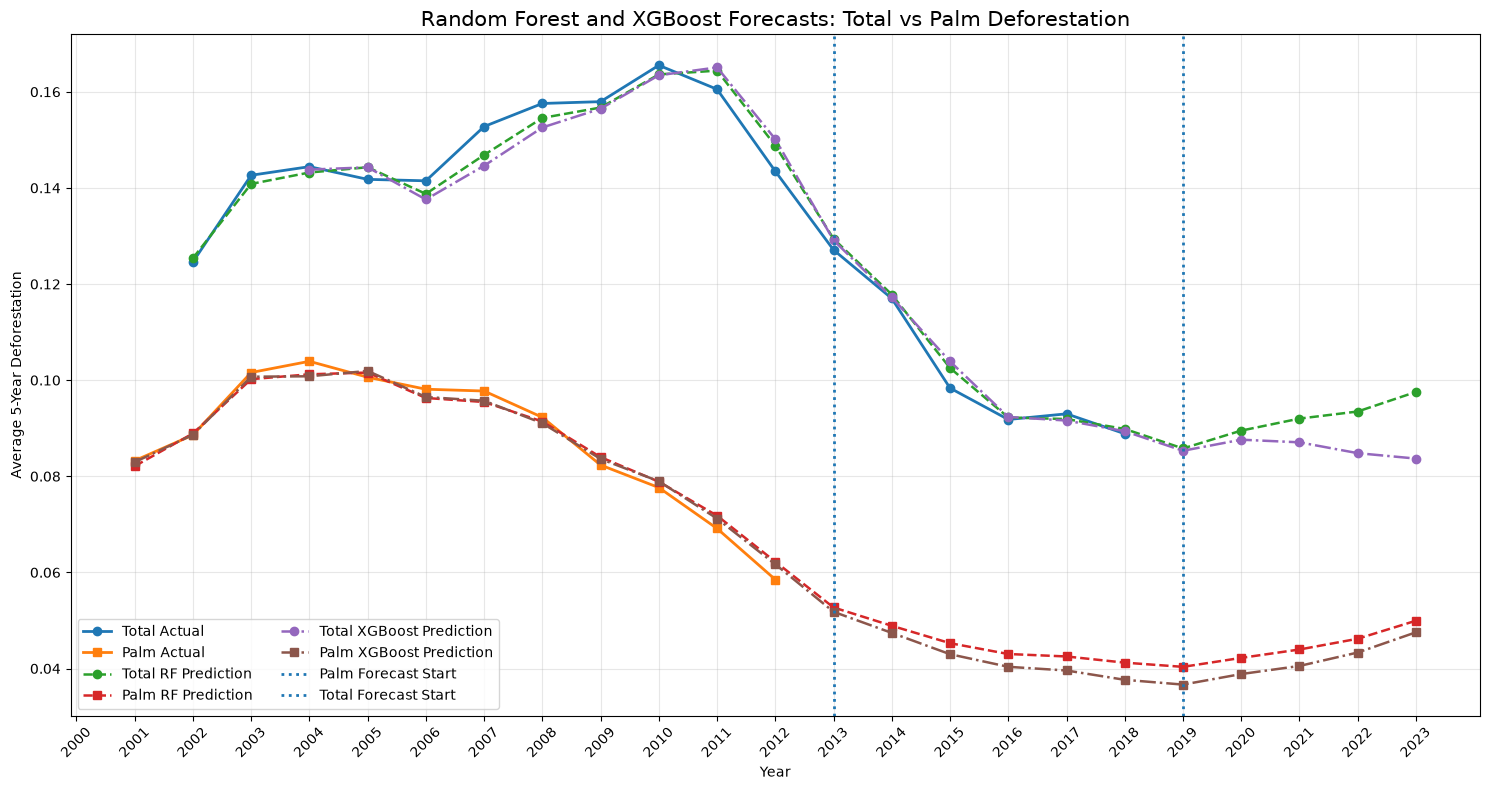

In [25]:
# Final combined plot: Random Forest and XGBoost for Total and Palm
plt.figure(figsize=(15, 8))

# Actual series
plt.plot(actual_total_rf.index, actual_total_rf.values, "o-", linewidth=2, label="Total Actual")
plt.plot(actual_mean_palm_rf.index, actual_mean_palm_rf.values, "s-", linewidth=2, label="Palm Actual")

# Random Forest predictions
plt.plot(prediction_total_rf.index, prediction_total_rf.values, "o--", linewidth=1.8, label="Total RF Prediction")
plt.plot(prediction_mean_palm_rf.index, prediction_mean_palm_rf.values, "s--", linewidth=1.8, label="Palm RF Prediction")

# XGBoost predictions
plt.plot(prediction_total_xg.index, prediction_total_xg.values, "o-.", linewidth=1.8, label="Total XGBoost Prediction")
plt.plot(prediction_mean_palm_xg.index, prediction_mean_palm_xg.values, "s-.", linewidth=1.8, label="Palm XGBoost Prediction")

plt.axvline(2013, linestyle=":", linewidth=2, label="Palm Forecast Start")
plt.axvline(2019, linestyle=":", linewidth=2, label="Total Forecast Start")

plt.title("Random Forest and XGBoost Forecasts: Total vs Palm Deforestation", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Average 5-Year Deforestation")
plt.xticks(range(2000, 2024), rotation=45)
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


Ploty 

In [26]:
import sys
print(sys.executable)

/usr/local/bin/python3.12


In [27]:
import sys
!{sys.executable} -m pip install --upgrade nbformat ipython plotly


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3.12 install --upgrade pip


In [43]:
import plotly.graph_objects as go

fig = go.Figure()

# Actual
fig.add_trace(go.Scatter(x=actual_total_rf.index,y=actual_total_rf.values,mode="lines+markers",
                         name="Total Actual",line=dict(color="black", width=3),marker=dict(symbol="circle", size=7)))
fig.add_trace(go.Scatter(x=actual_mean_palm_rf.index,y=actual_mean_palm_rf.values, mode="lines+markers",name="Palm Actual",
                         line=dict(color="green", width=3),marker=dict(symbol="square", size=7)))

# Random Forest predictions
fig.add_trace(go.Scatter(x=prediction_total_rf.index,y=prediction_total_rf.values, mode="lines+markers",
                         name="Total RF Prediction",line=dict(color = "#4C78A8", width=2.5, dash="dash"),
                        marker=dict(symbol="circle-open", size=7)))

fig.add_trace(go.Scatter(x=prediction_mean_palm_rf.index,y=prediction_mean_palm_rf.values,mode="lines+markers",
                         name="Palm RF Prediction",line=dict(color="#005AB5", width=2.5, dash="dash"),
                           marker=dict(symbol="square-open", size=7)))

# XGBoost predictions
fig.add_trace(go.Scatter(x=prediction_total_xg.index,y=prediction_total_xg.values,mode="lines+markers",
                         name="Total XGBoost Prediction",
                         line=dict(color="#EF801E", width=2.5, dash="dot"),
                           marker=dict(symbol="diamond-open", size=7)))

fig.add_trace(go.Scatter(x=prediction_mean_palm_xg.index,y=prediction_mean_palm_xg.values,mode="lines+markers",
                         name="Palm XGBoost Prediction",line=dict(color = "#DC3220", width=2.5, dash="dot"),
                         marker=dict(symbol="diamond-open", size=7)))

# Forecast starting years
fig.add_vline(x=2013,line_dash="dot",line_width=2,line_color="gray",annotation_text="Palm Forecast Start",
              annotation_position="top left")
fig.add_vline(x=2019,line_dash="dot",line_width=2,line_color="gray",annotation_text="Total Forecast Start",
              annotation_position="top right")

fig.update_layout(title="Average 5 Year Deforestation Prediction",
                  xaxis_title="Year", yaxis_title="Average Deforestation",
                  template="plotly_white", width=1000, height=550,
                  hovermode="x unified", legend_title="Model",
                  plot_bgcolor = '#E5ECF6', margin=dict(l=50, r=20, t=50, b=50))

fig.update_xaxes(dtick=1,tickangle=-45,showgrid=True,gridcolor="white",gridwidth=1.5)
fig.update_yaxes(showgrid=True,gridcolor="white",gridwidth=1.5)
fig.update_yaxes(showgrid=True)
fig.show()